In [1]:
from pathlib import Path  # we have found all of the file form resting Respiration_ECG_Raw

folder = Path(r"C:\Users\saber\thesis_second_try\data\Rest\Respiration_ECG_Raw")
mat_files = sorted(folder.glob("*.mat"))

print("Number of .mat files:", len(mat_files))
print("all the files:")
for f in mat_files:
    print("  ", f.name)


Number of .mat files: 207
all the files:
   pupil_size_mm_estimation_LF.mat
   pupil_size_mm_interpolated_LF.mat
   resting_state_participant_010.mat
   resting_state_participant_011.mat
   resting_state_participant_012.mat
   resting_state_participant_013.mat
   resting_state_participant_014.mat
   resting_state_participant_015.mat
   resting_state_participant_016.mat
   resting_state_participant_017.mat
   resting_state_participant_018.mat
   resting_state_participant_019.mat
   resting_state_participant_020.mat
   resting_state_participant_021.mat
   resting_state_participant_022.mat
   resting_state_participant_023.mat
   resting_state_participant_024.mat
   resting_state_participant_025.mat
   resting_state_participant_026.mat
   resting_state_participant_027.mat
   resting_state_participant_028.mat
   resting_state_participant_029.mat
   resting_state_participant_030.mat
   resting_state_participant_031.mat
   resting_state_participant_033.mat
   resting_state_participant_034.mat

In [2]:
from scipy.io import loadmat   # picking one file to check 
import numpy as np

file_path = mat_files[4] 

print("Inspecting:", file_path.name)

mat = loadmat(file_path, squeeze_me=True, struct_as_record=False)

def find_arrays(obj, prefix=""):
    if hasattr(obj, "_fieldnames"):
        for f in obj._fieldnames:
            find_arrays(getattr(obj, f), prefix + f + ".")
    elif isinstance(obj, np.ndarray) and np.issubdtype(obj.dtype, np.number):
        print(prefix[:-1], "shape:", obj.shape)

for k in mat:
    if not k.startswith("__"):
        find_arrays(mat[k], k + ".")


Inspecting: resting_state_participant_012.mat
resting_state.Thermopod shape: (310058,)
resting_state.Cannula shape: (310058,)
resting_state.Fingerpulse shape: (310058,)
resting_state.ECG shape: (310058,)
resting_state.inhPeaks shape: (72,)
resting_state.exhPeaks shape: (72,)
resting_state.inhOnset shape: (72,)
resting_state.exhOnset shape: (72,)
resting_state.Phase shape: (304324,)
resting_state.inhPeaks_C shape: (70,)
resting_state.exhPeaks_C shape: (70,)
resting_state.inhOnset_C shape: (70,)
resting_state.exhOnset_C shape: (70,)
resting_state.Phase_C shape: (305293,)


In [3]:
import ecg_plot
import matplotlib.pyplot as plt
from ecgprep import preprocess, plot_helpers


we get these 4 singals: 
- resting_state.Thermopod shape: (310058,)
- resting_state.Cannula shape: (310058,)
- resting_state.Fingerpulse shape: (310058,)
- resting_state.ECG shape: (310058,)

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import ecg_plot
import scipy
from scipy.io import loadmat
from scipy.signal import resample_poly
from ecgprep import preprocess

mat_path = r"C:\Users\saber\thesis_second_try\data\Rest\Respiration_ECG_Raw\resting_state_participant_012.mat"
m = loadmat(mat_path, squeeze_me=True, struct_as_record=False)
print(m)

fs = 1000
ecg = np.asarray(m["resting_state"].ECG).squeeze().reshape(1, -1)
fingerplus = np.asarray(m["resting_state"].Fingerpulse).squeeze().reshape(1, -1)
cannula = np.asarray(m["resting_state"].Cannula).squeeze().reshape(1, -1)
thermopod = np.asarray(m["resting_state"].Thermopod).squeeze().reshape(1, -1)
print(ecg)



{'__header__': b'MATLAB 5.0 MAT-file, Platform: PCWIN64, Created on: Fri Feb  2 11:44:46 2024', '__version__': '1.0', '__globals__': [], 'resting_state': <scipy.io.matlab._mio5_params.mat_struct object at 0x0000023A9F5BB370>}
[[0.00034375 0.000275   0.00035    ... 0.00034375 0.00041875 0.00035   ]]


# high-pass baseline filter 

--> Hade to move it up for the correct ordering ¨


In [15]:
import scipy.signal as sgn
# https://github.com/antonior92/ecg-preprocessing/blob/64a2715b15ea5ee1a482e5319d2cbaf45edef6f4/ecgprep/preprocess.py#L30C1-L40C15
def remove_baseline_filter(sample_rate):
    fc = 0.8   # Hz cutoff
    fst = 0.2  # Hz stopband edge
    rp = 0.5   # dB passband ripple
    rs = 40    # dB stopband attenuation

    wn = fc / (sample_rate / 2)
    wst = fst / (sample_rate / 2)

    order, _ = sgn.ellipord(wn, wst, rp, rs)
    sos = sgn.iirfilter(order, wn, rp, rs, btype="high", ftype="ellip", output="sos")
    return sos


import numpy as np

# singnals are shape (1, N)
sos = remove_baseline_filter(sample_rate=fs)
print(sos.shape)

# filter along the last axis (time)
ecg_baseline_removed = sgn.sosfiltfilt(sos, ecg, axis=-1)
fingerplus_baseline_removed = sgn.sosfiltfilt(sos, fingerplus, axis=-1)
cannula_baseline_removed = sgn.sosfiltfilt(sos, cannula, axis=-1)
thermopod_baseline_removed = sgn.sosfiltfilt(sos, thermopod, axis=-1)

print("ecg shape:", ecg_baseline_removed)
print("----")
print("fingerplus shape:", fingerplus_baseline_removed)
print("----")
print("cannula shape:", cannula_baseline_removed)
print("----")
print("thermod shape:", thermopod_baseline_removed)



(2, 6)
ecg shape: [[-1.00812069e-05 -7.89640485e-05 -4.09770330e-06 ...  9.80161316e-06
   8.52065772e-05  1.68647891e-05]]
----
fingerplus shape: [[0.00164479 0.00227425 0.00293495 ... 0.01205776 0.0111926  0.01033402]]
----
cannula shape: [[0.0015415  0.00153041 0.00151891 ... 0.00021337 0.0001985  0.00018334]]
----
thermod shape: [[-0.00450045 -0.0045707  -0.00312544 ...  0.01003463  0.00840253
   0.00644418]]


# Resample everything to 60 Hz 

ecg_60 shape: (1, 18604)
fingerplus_60 shape: (1, 18604)
cannula_60 shape: (1, 18604)
thermpod_60 shape: (1, 18604)


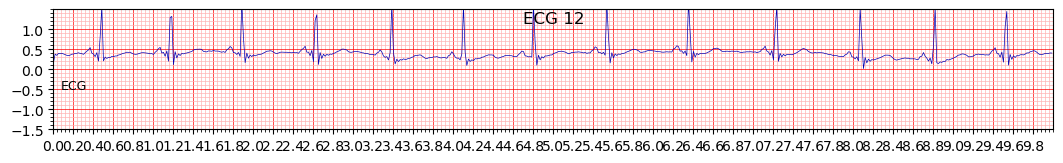

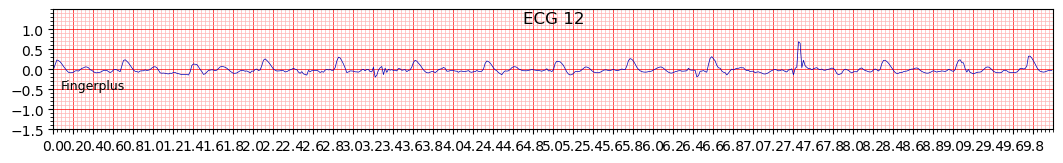

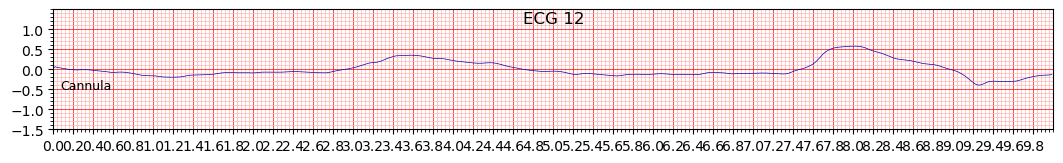

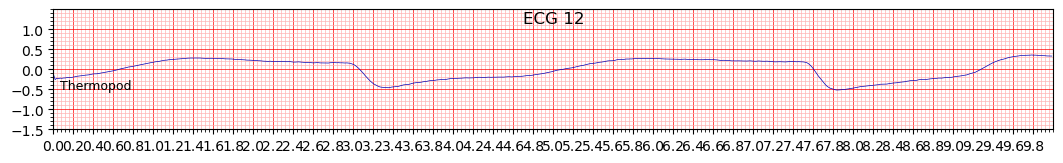

In [ ]:

from scipy.signal import resample_poly

ecg_60= scipy.signal.resample_poly(ecg, up=60, down=1000, axis=-1)
fingerplus_60= scipy.signal.resample_poly(fingerplus, up=60, down=1000, axis=-1)
cannula_60= scipy.signal.resample_poly(cannula, up=60, down=1000, axis=-1)
thermpod_60= scipy.signal.resample_poly(thermopod, up=60, down=1000, axis=-1)


# OBS I Adjusted there from volt to minivolt
print("ecg_60 shape:", ecg_60.shape)
print("fingerplus_60 shape:", fingerplus_60.shape)
print("cannula_60 shape:", cannula_60.shape)
print("thermpod_60 shape:", thermpod_60.shape)

# scale for plotting: volts -> millivolts
# ecg *1000
# finger * 10
# Thermopod as is 
# Cannula * 10 
ecg_60_mv = ecg_60 * 1000
fingerplus_60= fingerplus_60 * 10 
cannula_60 = cannula_60 * 10 

import ecg_plot
import matplotlib.pyplot as plt

lead_index_ecg = ["ECG"] * ecg_60_mv.shape[0]
lead_index_fin = ["Fingerplus"] * fingerplus_60.shape[0]
lead_index_can = ["Cannula"] * cannula_60.shape[0]
lead_index_them = ["Thermopod"] * thermpod_60.shape[0]

# plot a shorter window 
fs_out = 60
seconds = 10
n = fs_out * seconds

ecg_plot.plot(ecg_60_mv[:, :n], sample_rate=fs_out, lead_index=lead_index_ecg, style="b", columns=1)
ecg_plot.plot(fingerplus_60[:, :n], sample_rate=fs_out, lead_index=lead_index_fin, style="b", columns=1)
ecg_plot.plot(cannula_60[:, :n], sample_rate=fs_out, lead_index=lead_index_can, style="b", columns=1)
ecg_plot.plot(thermpod_60[:, :n], sample_rate=fs_out, lead_index=lead_index_them, style="b", columns=1)
plt.show()


# baseline filter

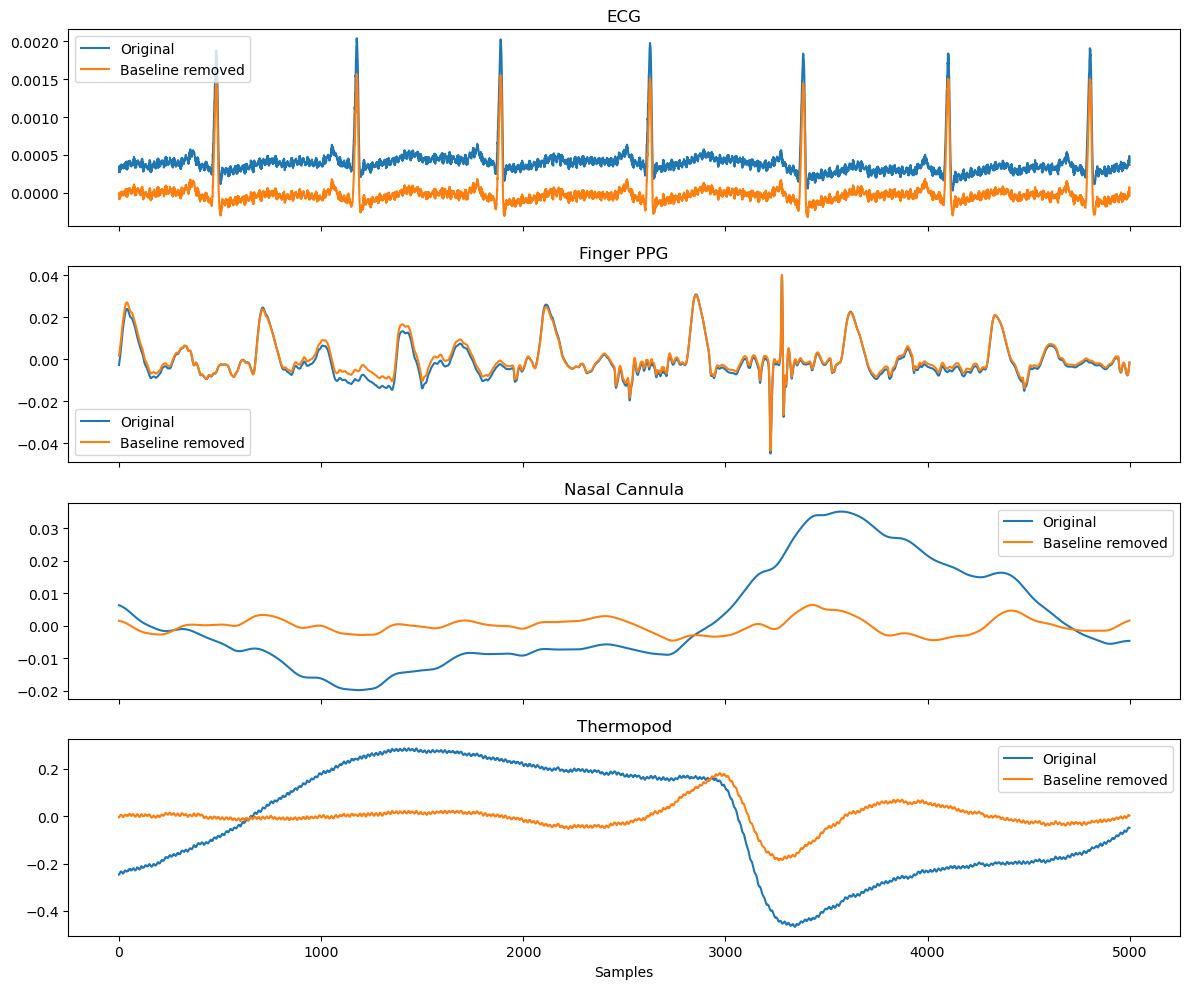

In [ ]:
# plt.figure(figsize=(12,4))
# plt.plot(ecg[0, :5000], label="Original")
# plt.plot(ecg_baseline_removed[0, :5000], label="Baseline removed")
# plt.plot(fingerplus[0, :5000], label="Original")
# plt.plot(fingerplus_baseline_removed[0, :5000], label="Baseline removed")
# plt.plot(cannula[0, :5000], label="Original")
# plt.plot(cannula_baseline_removed[0, :5000], label="Baseline removed")
# plt.plot(thermopod[0, :5000], label="Original")
# plt.plot(thermopod_baseline_removed[0, :5000], label="Baseline removed")
# plt.legend()
# plt.title("Effect of Baseline Removal")
# plt.show()

import matplotlib.pyplot as plt

n = 5000  # number of samples to show

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

# ECG --> obs this is before the v to mv
axes[0].plot(ecg[0, :n], label="Original")
axes[0].plot(ecg_baseline_removed[0, :n], label="Baseline removed")
axes[0].set_title("ECG")
axes[0].legend()

# Finger PPG
axes[1].plot(fingerplus[0, :n], label="Original")
axes[1].plot(fingerplus_baseline_removed[0, :n], label="Baseline removed")
axes[1].set_title("Finger PPG")
axes[1].legend()

# Cannula
axes[2].plot(cannula[0, :n], label="Original")
axes[2].plot(cannula_baseline_removed[0, :n], label="Baseline removed")
axes[2].set_title("Nasal Cannula")
axes[2].legend()

# Thermopod
axes[3].plot(thermopod[0, :n], label="Original")
axes[3].plot(thermopod_baseline_removed[0, :n], label="Baseline removed")
axes[3].set_title("Thermopod")
axes[3].legend()

plt.xlabel("Samples")
plt.tight_layout()
plt.show()


# spliting
- Window size 2048
- Number of windows = 18603 / 2048 = 9


In [ ]:


import numpy as np

win_len = 2048  #  windows size

signals = {
    "ECG_mV": ecg_60_mv[0],
    "Cannula": cannula_60[0],
    "Fingerplus": fingerplus_60[0],
    "Thermopod": thermpod_60[0],
}

windows_dict = {}

for name, x in signals.items():
   
    starts = np.arange(0, len(x) - win_len + 1, win_len)
    windows = np.stack([x[s:s+win_len] for s in starts])

    windows_dict[name] = windows

    print(f"\n{name}")
    print("  x length:", len(x))
    print("  windows shape:", windows.shape)
    print("  leftover samples dropped:", len(x) - len(starts) * win_len)



ECG_mV
  x length: 18604
  windows shape: (9, 2048)
  leftover samples dropped: 172

Cannula
  x length: 18604
  windows shape: (9, 2048)
  leftover samples dropped: 172

Fingerplus
  x length: 18604
  windows shape: (9, 2048)
  leftover samples dropped: 172

Thermopod
  x length: 18604
  windows shape: (9, 2048)
  leftover samples dropped: 172


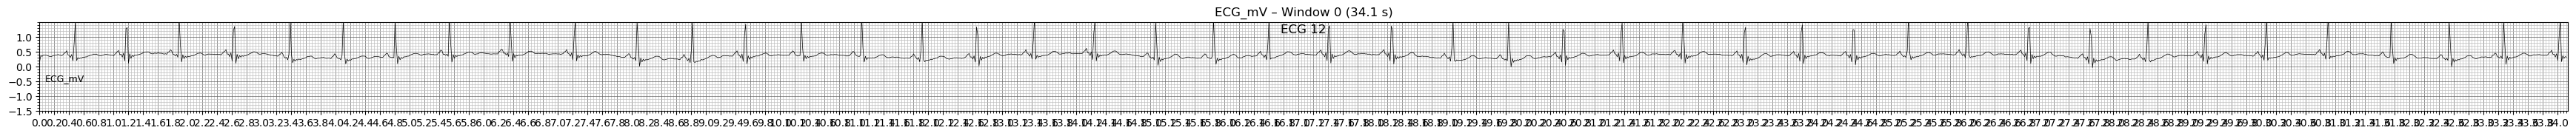

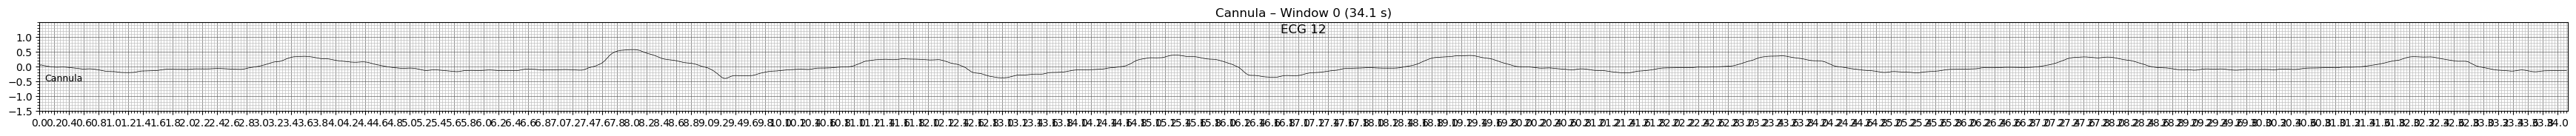

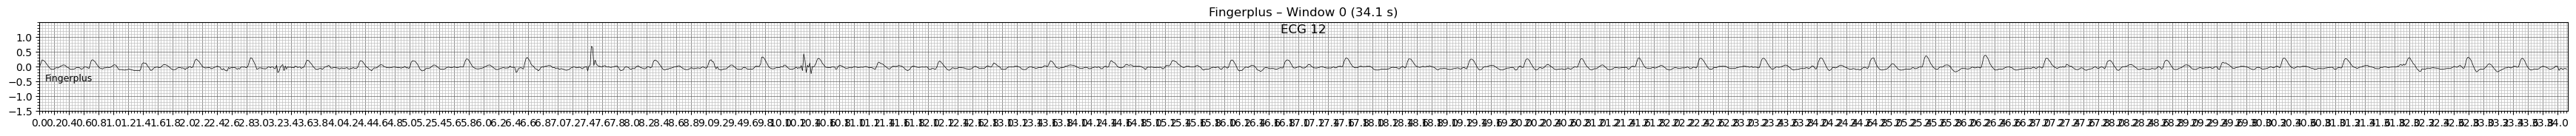

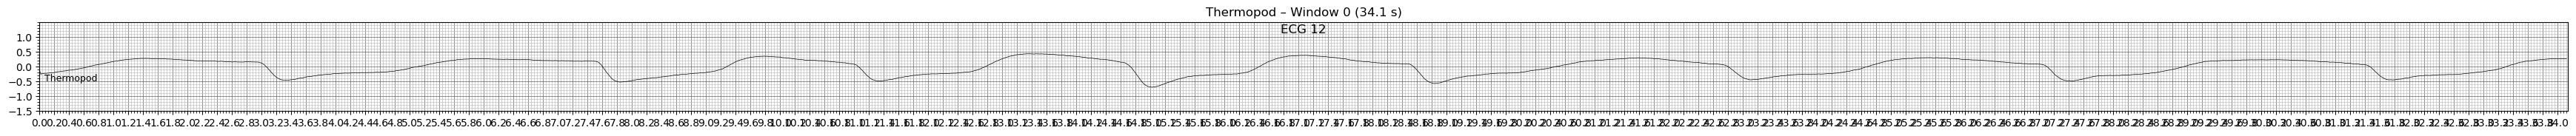

In [ ]:


import matplotlib.pyplot as plt
import ecg_plot

fs = 60
i = 0  # window index

for name, win_array in windows_dict.items():
    win = win_array[i].reshape(1, -1)  # (1, samples)

    ecg_plot.plot(
        win,
        sample_rate=fs,
        lead_index=[name],
        style="bw",
        columns=1
    )

    # AI used here
    # Override the default "ECG 12" title
    plt.gca().set_title(f"{name} – Window {i} ({win.shape[1]/fs:.1f} s)")
    plt.show()


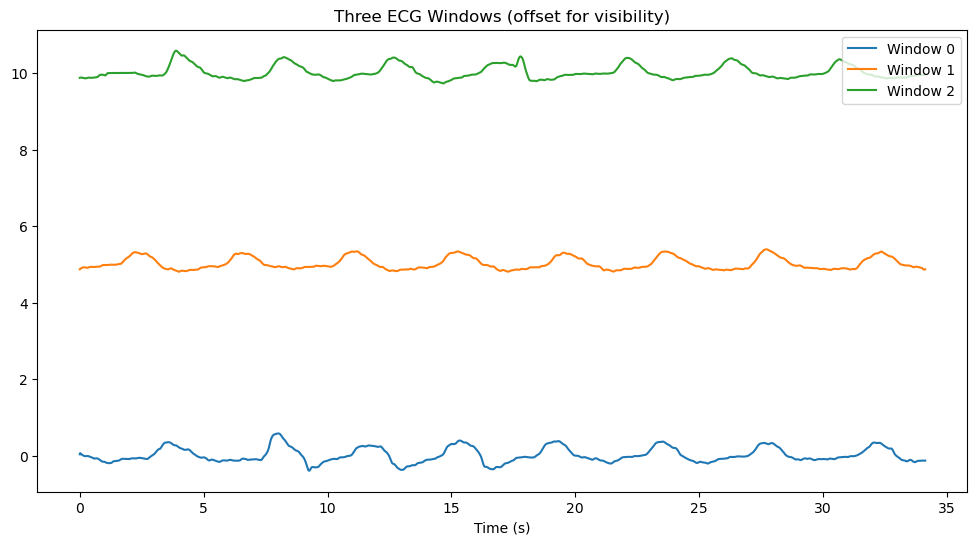

In [69]:
import matplotlib.pyplot as plt

fs = 60
t = np.arange(win_len) / fs

plt.figure(figsize=(12,6))

for i in range(min(3, len(windows))):
    plt.plot(t, windows[i] + i*5, label=f"Window {i}")  # offset for visibility

plt.xlabel("Time (s)")
plt.title("Three ECG Windows (offset for visibility)")
plt.legend()
plt.show()


I have preprossed one file form ecg! What to do next is TODO: 

- Do preprocessing for alla of the files NOW !!! 
- save all the preprocessed files in numpy dic tensor " tensor 9 x 4 x 2048 (n_windows x n_signals x window_size)"
---> stack in differe dimentionn, stack in top of it 
- what do you mean with the output 9X1 vecktor ??? 


Got answer about the scaling: 
---> have different scaling for each signal typ so that they look pretty much similare 
- ecg *1000
- finger * 10
- Thermopod as is 
- Cannula * 10 

In [ ]:
signal_order = ["ECG_mV", "Fingerplus", "Cannula", "Thermopod"]
tensor = np.stack([windows_dict[name] for name in signal_order], axis=1)
print(tensor.shape)



what we want to do is have this shape now : (205 × 9, 4, 2048) - "(( n_pations_files* n_windows) x n_signals x window_size)"



##  Re-doing everything in a more optimized way

In [ ]:
from pathlib import Path
import numpy as np
import scipy.signal as sgn
from scipy.io import loadmat


folder = Path(r"C:\Users\saber\thesis_second_try\data\Rest\Respiration_ECG_Raw")

FS_IN = 1000
FS_OUT = 60
WIN_LEN = 2048
STRIDE = WIN_LEN  # non-overlap

SIGNAL_ORDER = ["ECG_mV", "Fingerpulse", "Cannula", "Thermopod"]
# Optimal scales for each 
SCALE = {
    "ECG_mV": 1000.0,      # V -> mV
    "Fingerpulse": 10.0,
    "Cannula": 10.0,
    "Thermopod": 1.0
}


# Baseline Filter function
# https://github.com/antonior92/ecg-preprocessing/blob/64a2715b15ea5ee1a482e5319d2cbaf45edef6f4/ecgprep/preprocess.py#L30C1-L40C15
def remove_baseline_filter(sample_rate: int):
    fc = 0.8
    fst = 0.2
    rp = 0.5
    rs = 40

    wn = fc / (sample_rate / 2)
    wst = fst / (sample_rate / 2)
    order, _ = sgn.ellipord(wn, wst, rp, rs)
    sos = sgn.iirfilter(order, wn, rp, rs, btype="high", ftype="ellip", output="sos")
    return sos

SOS = remove_baseline_filter(FS_IN)


# One file -> (n_windows, 4, 2048)
def preprocess_one_file(mat_path: Path) -> np.ndarray:
    m = loadmat(mat_path, squeeze_me=True, struct_as_record=False)
    rs = m["resting_state"]


    # baseline removal 
    ecg_f   = sgn.sosfiltfilt(SOS, (rs.ECG))
    fp_f    = sgn.sosfiltfilt(SOS, rs.Fingerpulse)
    can_f   = sgn.sosfiltfilt(SOS, rs.Cannula)
    therm_f = sgn.sosfiltfilt(SOS, rs.Thermopod)

    # resample to 60 Hz 
    ecg_60   = sgn.resample_poly(ecg_f,   up=FS_OUT, down=FS_IN)
    fp_60    = sgn.resample_poly(fp_f,    up=FS_OUT, down=FS_IN)
    can_60   = sgn.resample_poly(can_f,   up=FS_OUT, down=FS_IN)
    therm_60 = sgn.resample_poly(therm_f, up=FS_OUT, down=FS_IN)

    # scale
    ecg_60   = ecg_60   * SCALE["ECG_mV"]
    fp_60    = fp_60    * SCALE["Fingerpulse"]
    can_60   = can_60   * SCALE["Cannula"]
    therm_60 = therm_60 * SCALE["Thermopod"]

    # windowing
    L = len(ecg_60)  # Since all signals same length after resample
    starts = np.arange(0, L - WIN_LEN + 1, WIN_LEN)


    n_windows = len(starts)
    tensor = np.zeros((n_windows, 4, WIN_LEN), dtype=np.float32)

    for i, s in enumerate(starts):
        tensor[i, 0, :] = ecg_60[s:s+WIN_LEN]
        tensor[i, 1, :] = fp_60[s:s+WIN_LEN]
        tensor[i, 2, :] = can_60[s:s+WIN_LEN]
        tensor[i, 3, :] = therm_60[s:s+WIN_LEN]

    return tensor


# Run over all participant files
mat_files = sorted(folder.glob("*.mat"))

participant_files = []
for f in mat_files:
    if f.name.startswith("resting_state_participant_"): # Got ride of the first 2 files
        participant_files.append(f)

print("Total .mat files:", len(mat_files))
print("Participant files:", len(participant_files))

# Added a "failed check" with Ai 
tensors_by_participant = {}
failed = []

for f in participant_files:
    try:
        tensor = preprocess_one_file(f)
        tensors_by_participant[f.stem] = tensor
    except Exception as e:
        failed.append((f.name, str(e)))

print("Processed:", len(tensors_by_participant))
print("Failed:", len(failed))

# Stacking to the format  (205,9, 4, 2048)
# Ai was used here 
if len(failed) == 0 and len(tensors_by_participant) > 0:
    keys = sorted(tensors_by_participant.keys())
    all_data = np.stack([tensors_by_participant[k] for k in keys], axis=0)
    print("all_data shape:", all_data.shape) 


Total .mat files: 207
Participant files: 205
Processed: 205
Failed: 0
all_data shape: (205, 9, 4, 2048)


In [31]:
all_data

array([[[[-1.44109763e-02, -2.33213939e-02, -3.43135744e-02, ...,
          -7.06182644e-02, -7.63332099e-02, -8.39938447e-02],
         [-1.69982061e-01, -3.43078882e-01, -1.53854027e-01, ...,
           1.86243057e-02,  1.15032475e-02,  3.35661159e-03],
         [ 9.76870283e-02,  1.85213909e-01,  1.38457343e-01, ...,
          -5.20643033e-02, -5.29435612e-02, -4.88226078e-02],
         [-2.35217176e-02, -5.23756556e-02, -5.35447970e-02, ...,
           3.39912474e-02,  3.02451383e-02,  1.92127246e-02]],

        [[-7.03699142e-02, -7.24466667e-02, -8.08232576e-02, ...,
          -1.51563600e-01, -8.49083140e-02, -2.15501159e-01],
         [-4.45063366e-03, -7.34506454e-03, -1.11020645e-02, ...,
          -1.40425162e-02, -6.36741668e-02, -7.19534457e-02],
         [-4.06846218e-02, -3.06263808e-02, -2.00384185e-02, ...,
           1.22108743e-01,  1.22059561e-01,  1.16388358e-01],
         [ 5.56708453e-03, -1.06561836e-02, -2.03618836e-02, ...,
          -1.55116478e-02, -1.487801

In [43]:
import pandas as pd

Path_subject = r"C:\Users\saber\thesis_second_try\data\Rest\Subject info_study_1.csv"
df_subject = pd.read_csv(Path_subject)

df_subject.head()


,Subject Number,Gender,Age
0,1,Male,27
1,2,Female,29
2,3,Female,24
3,4,Male,21
4,5,Female,20


In [ ]:
gender_map = {'Male': 1, 'Female': 0}

df_subject['Gender'] = df_subject['Gender'].map(gender_map).astype('Int64') # .astype('Int64') converted 0.0 or 1.0 to 0 and 1 


df_subject.head()

,Subject Number,Gender,Age
0,1,1,27
1,2,0,29
2,3,0,24
3,4,1,21
4,5,0,20


What to do next is to create a cnn model and predict the genders 
- Have asked Reza about the high number of pationed data